In [1]:
# sudo apt install python3-venv
# python3 -m venv myenv
# source myenv/bin/activate
# pip install notebook
# jupyter notebook
# pip install tensorflow keras pandas numpy scikit-learn matplotlib seaborn

         Date      Open      High       Low     Close  Adj Close     Volume
0  2004-08-19  2.490664  2.591785  2.390042  2.499133   2.499133  897427216
1  2004-08-20  2.515820  2.716817  2.503118  2.697639   2.697639  458857488
2  2004-08-23  2.758411  2.826406  2.716070  2.724787   2.724787  366857939
3  2004-08-24  2.770615  2.779581  2.579581  2.611960   2.611960  306396159
4  2004-08-25  2.614201  2.689918  2.587302  2.640104   2.640104  184645512
Epoch 1/10


C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0174
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.9407e-05
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 7.6729e-05
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 7.0185e-05
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 5.2128e-05
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 4.7865e-05
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 4.0234e-05
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 4.1377e-05
Epoch 9/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3.5036e-05
Epoch 10/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 3.2934e-05
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


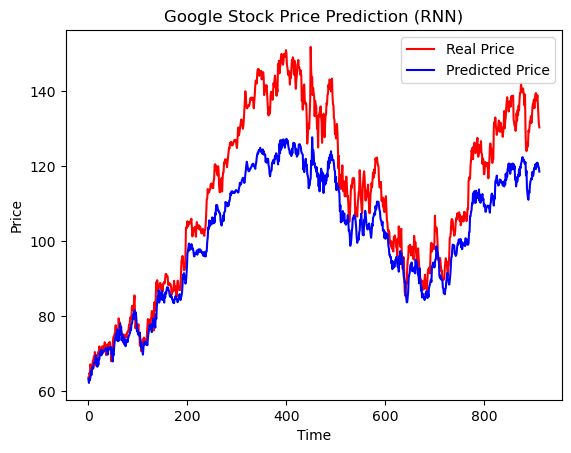

MSE: 144.63829835542774
RMSE: 12.026566357669497
MAE: 9.935974724802117


In [4]:
# Google Stock Price Prediction using RNN

# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv("goog.csv")  
print(df.head())


# Use 'Open' price
data = df[['Open']].values

# ==============================
# 3. SCALING
# ==============================
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# ==============================
# 4. TRAIN-TEST SPLIT
# ==============================
train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

# ==============================
# 5. CREATE SEQUENCES (60 DAYS)
# ==============================
def create_dataset(dataset):
    X, y = [], []
    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

# Reshape for RNN [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ==============================
# 6. BUILD RNN MODEL
# ==============================
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

# ==============================
# 7. COMPILE
# ==============================
model.compile(optimizer='adam', loss='mean_squared_error')

# ==============================
# 8. TRAIN
# ==============================
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

# ==============================
# 9. PREDICT
# ==============================
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

# ==============================
# 10. PLOT RESULTS
# ==============================
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

# ==============================
# 11. EVALUATION
# ==============================
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(real, predicted)
mae = mean_absolute_error(real, predicted)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

In [5]:
# ==============================
# FUTURE PREDICTION (NEXT DAY)
# ==============================

# Take last 60 days from full dataset
last_60_days = data_scaled[-60:]

# Reshape for model
last_60_days = last_60_days.reshape(1, 60, 1)

# Predict next day
future_price = model.predict(last_60_days)

# Convert back to original scale
future_price = scaler.inverse_transform(future_price)

print("Next Day Predicted Price:", future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Next Day Predicted Price: 117.06171


In [ ]:


# ## 1. Importing Required Libraries

# ```python
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# ```

# * `numpy` is used for numerical operations.
# * `pandas` is used to load and manipulate the dataset.
# * `matplotlib` is used for plotting graphs.

# ```python
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, SimpleRNN
# ```

# * `MinMaxScaler` is used to normalize data.
# * `Sequential` is used to build the neural network.
# * `Dense` is a fully connected layer.
# * `SimpleRNN` is a recurrent neural network layer.

# ---

# ## 2. Loading Dataset

# ```python
# df = pd.read_csv("goog.csv")
# print(df.head())
# ```

# * Loads the dataset containing Google stock prices.
# * Displays the first 5 rows to verify data.

# ```python
# data = df[['Open']].values
# ```

# * Selects only the "Open" price column.
# * Converts it into a NumPy array.

# ---

# ## 3. Data Scaling

# ```python
# scaler = MinMaxScaler(feature_range=(0,1))
# data_scaled = scaler.fit_transform(data)
# ```

# * Scales data between 0 and 1.
# * Helps the neural network learn faster and better.

# ---

# ## 4. Train-Test Split

# ```python
# train_size = int(len(data_scaled) * 0.8)
# ```

# * Calculates 80% of data for training.

# ```python
# train_data = data_scaled[:train_size]
# test_data = data_scaled[train_size:]
# ```

# * Splits dataset into training and testing sets.

# ---

# ## 5. Creating Sequences (60 Time Steps)

# ```python
# def create_dataset(dataset):
#     X, y = [], []
# ```

# * Function to create input-output pairs for time series.

# ```python
#     for i in range(60, len(dataset)):
# ```

# * Starts from index 60 to use previous 60 days as input.

# ```python
#         X.append(dataset[i-60:i, 0])
# ```

# * Stores last 60 days data as input.

# ```python
#         y.append(dataset[i, 0])
# ```

# * Stores current day's value as output.

# ```python
#     return np.array(X), np.array(y)
# ```

# * Converts lists into NumPy arrays.

# ---

# ```python
# X_train, y_train = create_dataset(train_data)
# X_test, y_test = create_dataset(test_data)
# ```

# * Generates training and testing sequences.

# ---

# ### Reshaping Data for RNN

# ```python
# X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
# X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
# ```

# * Reshapes data into 3D format required by RNN:

#   * samples
#   * timesteps (60 days)
#   * features (1 value per day)

# ---

# ## 6. Building RNN Model

# ```python
# model = Sequential()
# ```

# * Initializes sequential model.

# ```python
# model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
# ```

# * First RNN layer with 50 neurons.
# * `return_sequences=True` passes output to next RNN layer.

# ```python
# model.add(SimpleRNN(50))
# ```

# * Second RNN layer with 50 neurons.

# ```python
# model.add(Dense(1))
# ```

# * Output layer with 1 neuron (predicted price).

# ---

# ## 7. Compiling Model

# ```python
# model.compile(optimizer='adam', loss='mean_squared_error')
# ```

# * `adam` optimizer updates weights.
# * `mean_squared_error` is used for regression tasks.

# ---

# ## 8. Training Model

# ```python
# history = model.fit(X_train, y_train, epochs=10, batch_size=32)
# ```

# * Trains model on training data.
# * `epochs=10` means data is passed 10 times.
# * `batch_size=32` processes 32 samples at a time.

# ---

# ## 9. Making Predictions

# ```python
# predicted = model.predict(X_test)
# ```

# * Predicts stock prices on test data.

# ---

# ### Inverse Scaling

# ```python
# predicted = scaler.inverse_transform(predicted)
# real = scaler.inverse_transform(y_test.reshape(-1,1))
# ```

# * Converts scaled values back to original prices.

# ---

# ## 10. Plotting Results

# ```python
# plt.plot(real, color='red', label='Real Price')
# plt.plot(predicted, color='blue', label='Predicted Price')
# ```

# * Plots actual vs predicted prices.

# ```python
# plt.title("Google Stock Price Prediction (RNN)")
# plt.xlabel("Time")
# plt.ylabel("Price")
# ```

# * Adds labels and title.

# ```python
# plt.legend()
# plt.show()
# ```

# * Displays the graph.

# ---

# ## 11. Model Evaluation

# ```python
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# ```

# * Imports evaluation metrics.

# ```python
# mse = mean_squared_error(real, predicted)
# mae = mean_absolute_error(real, predicted)
# rmse = np.sqrt(mse)
# ```

# * Calculates:

#   * MSE (Mean Squared Error)
#   * MAE (Mean Absolute Error)
#   * RMSE (Root Mean Squared Error)

# ```python
# print("MSE:", mse)
# print("RMSE:", rmse)
# print("MAE:", mae)
# ```

# * Prints evaluation results.
